In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("20-digitalskysurvey.csv")

In [3]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [4]:
df.shape

(10000, 18)

In [5]:
df.columns

Index(['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run', 'rerun', 'camcol',
       'field', 'specobjid', 'class', 'redshift', 'plate', 'mjd', 'fiberid'],
      dtype='object')

In [6]:
columns_to_drop = ["objid","specobjid","run","rerun","camcol","field"]

In [7]:
for i in columns_to_drop:
    df.drop(i, axis = 1 ,inplace = True)

In [8]:
df.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,STAR,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,STAR,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,GALAXY,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,STAR,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,STAR,0.000590,3306,54922,512


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   class     10000 non-null  object 
 8   redshift  10000 non-null  float64
 9   plate     10000 non-null  int64  
 10  mjd       10000 non-null  int64  
 11  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 937.6+ KB


In [10]:
df.isnull().sum()

ra          0
dec         0
u           0
g           0
r           0
i           0
z           0
class       0
redshift    0
plate       0
mjd         0
fiberid     0
dtype: int64

In [11]:
df[df.duplicated()]

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid


In [12]:
df.describe()

,ra,dec,u,g,r,i,z,redshift,plate,mjd,fiberid
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.529987,14.836148,18.619355,17.371931,16.840963,16.583579,16.422833,0.143726,1460.986400,52943.533300,353.069400
std,47.783439,25.212207,0.828656,0.945457,1.067764,1.141805,1.203188,0.388774,1788.778371,1511.150651,206.298149
min,8.235100,-5.382632,12.988970,12.799550,12.431600,11.947210,11.610410,-0.004136,266.000000,51578.000000,1.000000
25%,157.370946,-0.539035,18.178035,16.815100,16.173333,15.853705,15.618285,0.000081,301.000000,51900.000000,186.750000
50%,180.394514,0.404166,18.853095,17.495135,16.858770,16.554985,16.389945,0.042591,441.000000,51997.000000,351.000000
75%,201.547279,35.649397,19.259232,18.010145,17.512675,17.258550,17.141447,0.092579,2559.000000,54468.000000,510.000000
max,260.884382,68.542265,19.599900,19.918970,24.802040,28.179630,22.833060,5.353854,8410.000000,57481.000000,1000.000000


In [13]:
df["class"].value_counts()

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64

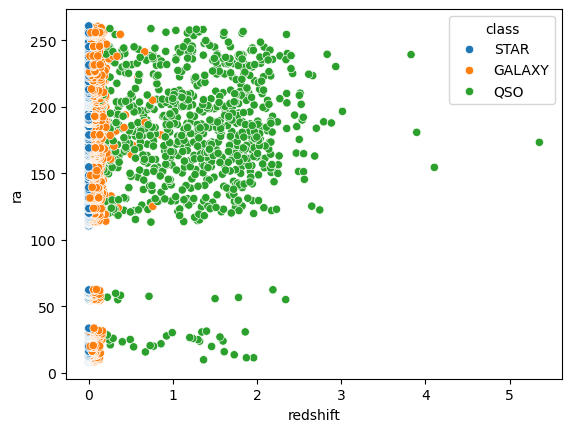

In [14]:
sns.scatterplot(x = df["redshift"], y = df["ra"], hue = df["class"])
plt.show()

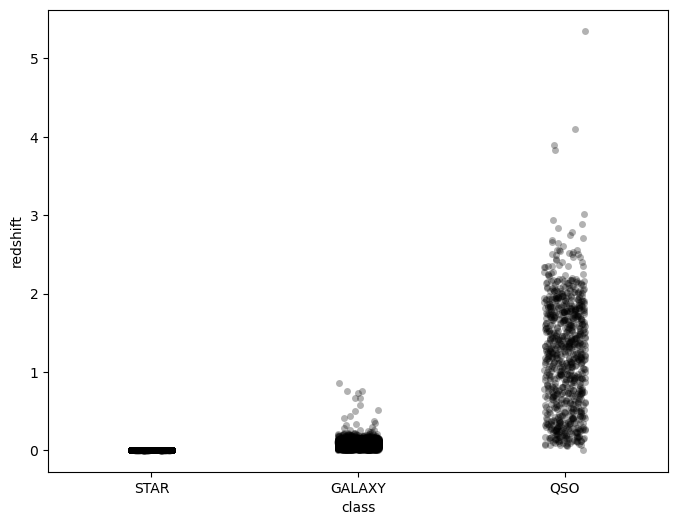

In [15]:
plt.figure(figsize=(8, 6))
sns.stripplot(x="class", y="redshift", data=df, color="black", alpha=0.3)
plt.show()

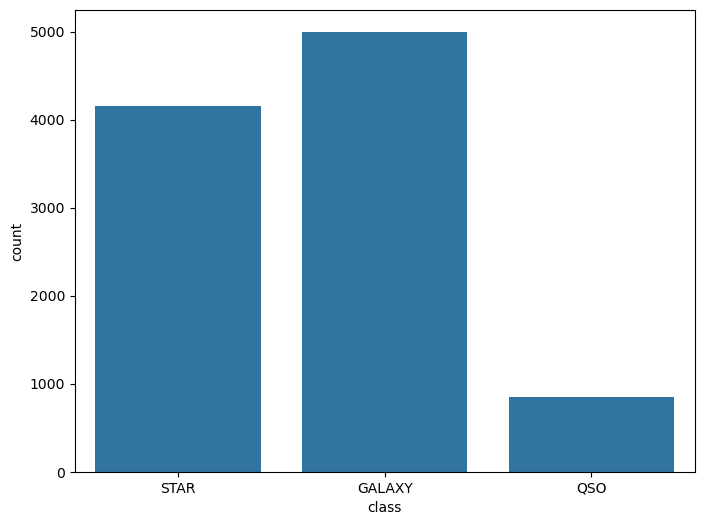

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(x="class", data=df)
plt.show()

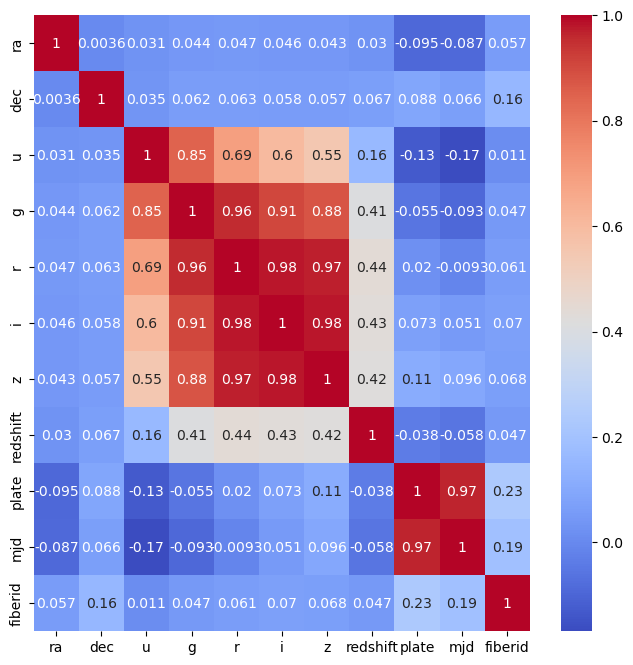

In [17]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

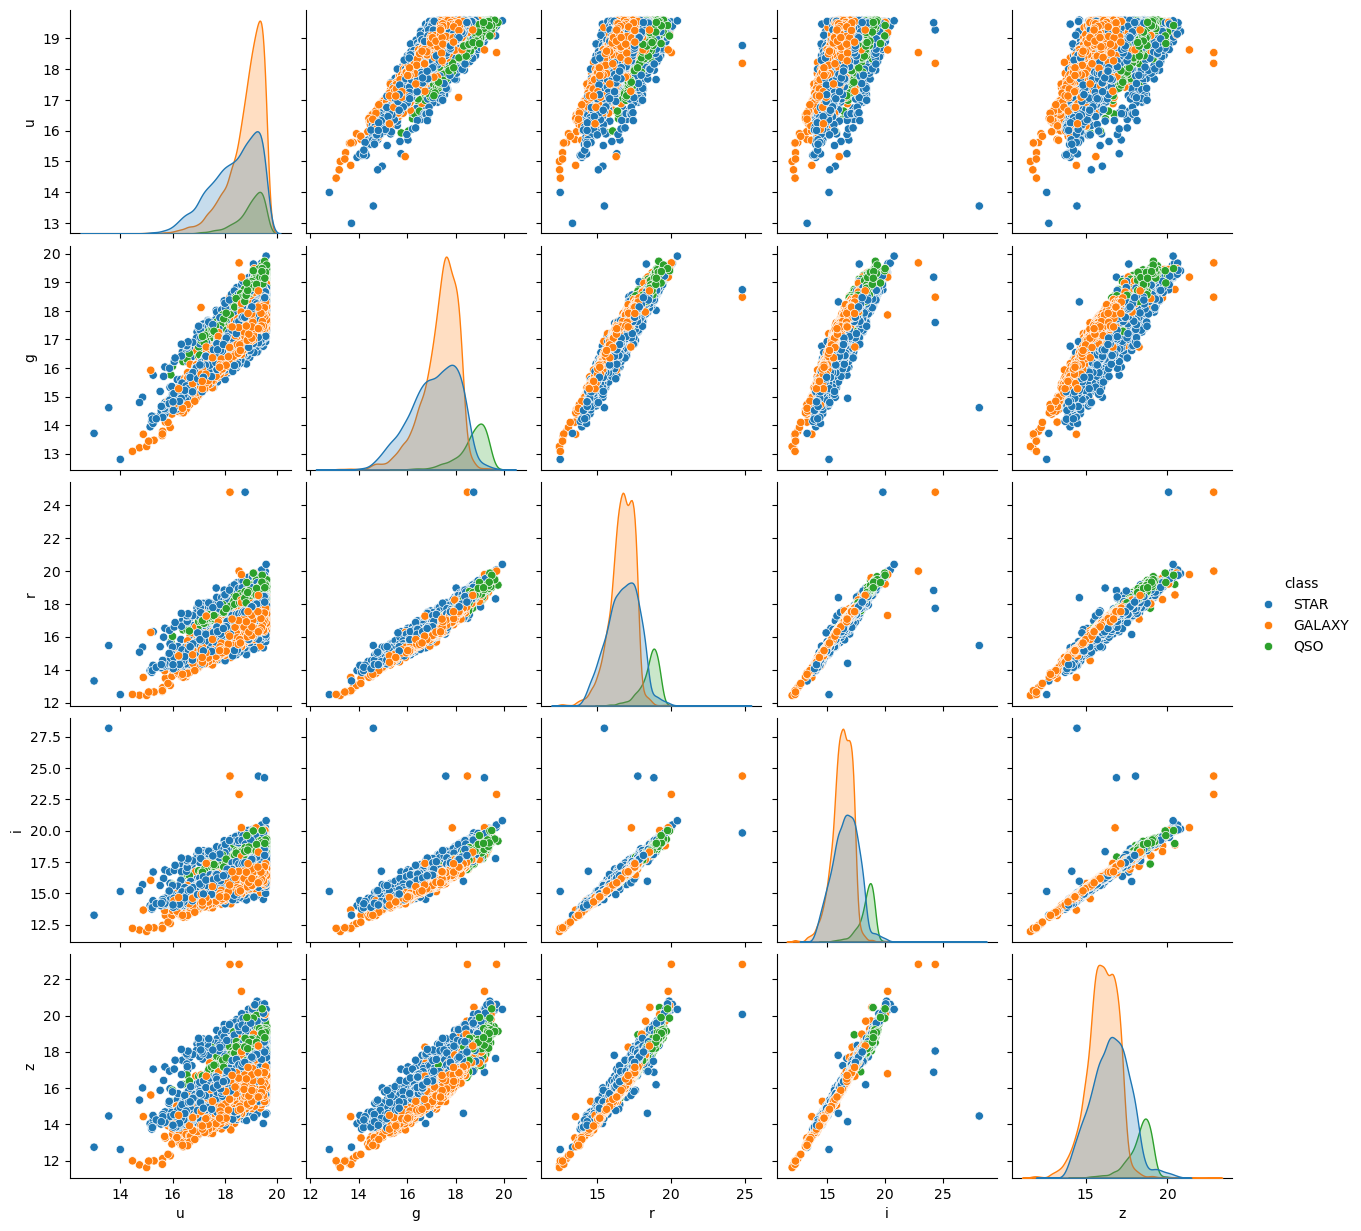

In [18]:
sns.pairplot(df, hue="class", vars=["u", "g", "r", "i", "z"])
plt.show()

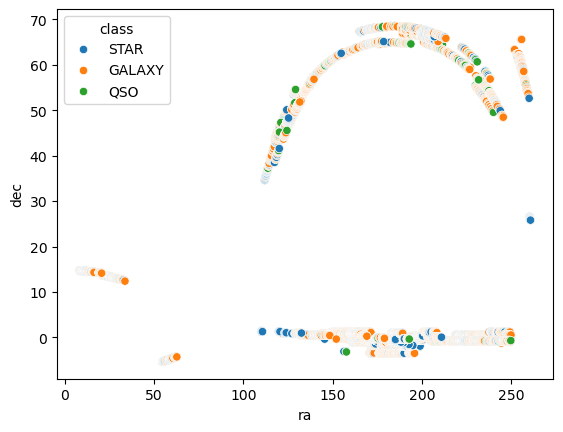

In [19]:
sns.scatterplot(x="ra", y="dec", hue="class", data=df)
plt.show()

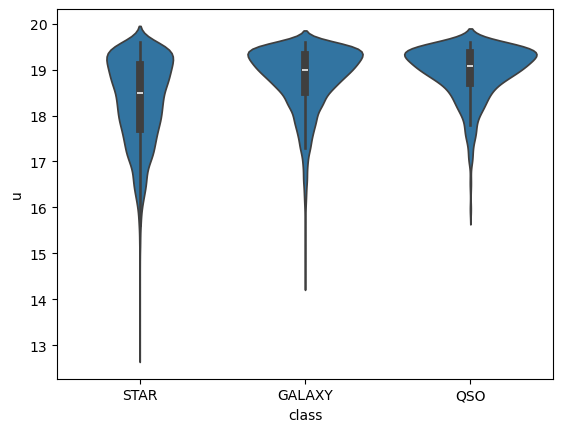

In [20]:
sns.violinplot(x="class", y="u", data=df)
plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# dependent feature
df["class"] = le.fit_transform(df["class"])

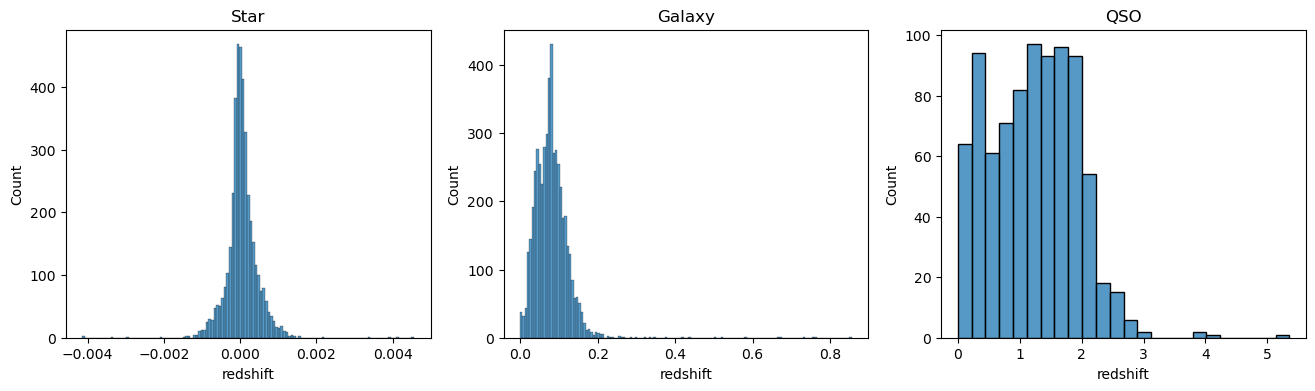

In [22]:
fig,axes = plt.subplots(nrows = 1 ,ncols = 3, figsize = (16,4))
ax = sns.histplot(df[df["class"] == 2].redshift, ax = axes[0])
ax.set_title("Star")
ax = sns.histplot(df[df["class"] == 0].redshift, ax = axes[1])
ax.set_title("Galaxy")
ax = sns.histplot(df[df["class"] == 1].redshift, ax = axes[2])
ax.set_title("QSO")
plt.show()

In [23]:
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > threshold:
                colname = corr.columns[i]
                columns_to_drop.add(colname)
    return columns_to_drop

In [24]:
correlation_for_dropping(df,0.80)

{'g', 'i', 'mjd', 'r', 'z'}

In [25]:
X = df.drop(columns=["class", "plate", "mjd", "fiberid","i","z"],axis = 1)
y = df["class"]

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33, random_state=15)

In [27]:
X_train.head()

,ra,dec,u,g,r,redshift
1385,225.476096,0.626575,17.13654,16.03048,15.62024,0.000030
5963,182.960919,-0.923741,18.46162,17.43633,17.02447,0.000627
5213,245.691205,1.243758,19.28122,17.97229,17.63551,0.024425
4979,181.629508,-0.856283,19.22520,17.81399,17.26950,0.000155
5333,120.199247,43.478352,19.40213,18.50578,18.17822,0.000492


In [28]:
!pip install xgboost

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [30]:
xgb = XGBClassifier(n_estimators = 100)
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test,y_pred))
print("Classification Report: \n",classification_report(y_test,y_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))

Accuracy Score:  0.9884848484848485
Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1687
           1       0.96      0.94      0.95       271
           2       0.99      1.00      1.00      1342

    accuracy                           0.99      3300
   macro avg       0.98      0.98      0.98      3300
weighted avg       0.99      0.99      0.99      3300

Confusion Matrix: 
 [[1668   11    8]
 [  14  256    1]
 [   4    0 1338]]


In [31]:
# hyperparameter tuning

In [32]:
params = {
    "n_estimators" : [100,150,200,250,300],
    "max_depth" : [5,8,12,20,30],
    "learning_rate" : [0.01,0.1,1],
    "colsample_bytree" : [0.3,0.6,1]
}

In [33]:
from sklearn.model_selection import RandomizedSearchCV

In [34]:
rsc = RandomizedSearchCV(
    estimator=XGBClassifier(),
    param_distributions=params,
    cv = 5,
    n_jobs=-1,
    random_state=15,
    verbose=1,
    scoring = "f1_macro",
    n_iter=50
)

In [35]:
rsc.fit(X_train,y_train)
y_pred = rsc.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test,y_pred))
print("Classification Report: \n",classification_report(y_test,y_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Accuracy Score:  0.9890909090909091
Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1687
           1       0.97      0.94      0.95       271
           2       0.99      1.00      1.00      1342

    accuracy                           0.99      3300
   macro avg       0.98      0.98      0.98      3300
weighted avg       0.99      0.99      0.99      3300

Confusion Matrix: 
 [[1671    9    7]
 [  16  254    1]
 [   3    0 1339]]


In [36]:
rsc.best_params_

{'n_estimators': 300,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 0.6}

In [37]:
xgb.feature_importances_

array([0.00724217, 0.00779309, 0.01403956, 0.0133045 , 0.00928392,
       0.9483367 ], dtype=float32)

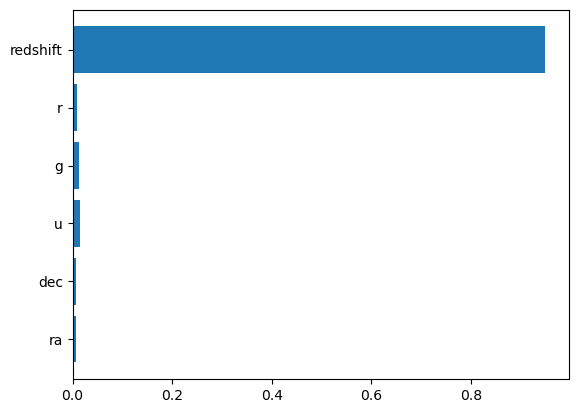

In [38]:
importances = xgb.feature_importances_
features = X_train.columns
plt.barh(features, importances)
plt.show()

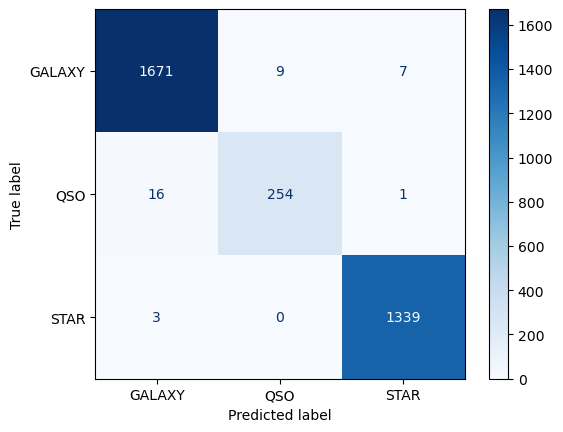

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(cmap="Blues")
plt.show()

In [40]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb, X, y, cv=5, scoring="f1_macro")
print(scores.mean(), scores.std())

0.979390614093542 0.0035993559996980802
